In [ ]:
!pip install connected-components-3d 
import cc3d


import numpy as np

from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
from scipy.ndimage import convolve
from scipy.ndimage import gaussian_filter

import heapq
print('IMPORT OK')

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

if 0:

    import pyvista as pv
    def show_voxel(data, is_label=True):
    
        vol = data.astype(np.float32)  # image  #mask  predict overlay_3d
        vol = vol / vol.max()  # scale to [0, 1]
        vol = vol ** 1.15
    
        # Wrap as a pyvista UniformGrid
        grid = pv.wrap(vol)
    
        # ----------------------------------------------------------
        # 3. Wrap volume as PyVista grid and attach label scalars
        if is_label:
            labels = data.astype(np.int32)
            grid["labels"] = labels.flatten(order="F")  # PyVista expects Fortran order
            cmap = "tab20"
        else:
            cmap="gray"
    
        # Normalized (optional, if you want float colors)
        opacity = np.ones(255)*0.8
        opacity[0] = 0.0
    
        # ----------------------------------------------------------
        plotter = pv.Plotter()
        if is_label:
            plotter.add_volume(
                grid,
                #shade=True,
                opacity=opacity,
                scalars="labels",
                cmap = "tab20",  # good for categorical colors 
            )
        else:
            plotter.add_volume(
                grid,
                # shade=True,
                # opacity="sigmoid",   # or "linear", "sigmoid_5", etc.
                opacity=opacity,
                cmap="gray",       
            )

# matlib 3d volume rendering is slow ... please use pyvista

def show_voxel_matplotlib(vol, color=None):
    """
    vol: 3D numpy array (e.g. probability or mask)
    threshold: values > threshold will be drawn as voxels
    """
    # boolean mask of voxels to draw
    #vol = vol[:10]
    max_label = vol.max()

    if color is None:
        # auto generate colors
        color = plt.cm.tab20(np.linspace(0, 1, max_label+1))

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")

    facecolors = np.zeros(vol.shape + (4,), dtype=float)
    for label in range(1,max_label+1):
        filled = vol==label
        facecolors[filled, :4] = color[label-1]    # RGBA tuple
        facecolors[filled,  3] = 0.6

    ax.voxels(vol!=0, facecolors=facecolors, edgecolor='none')

    ax.set_box_aspect([s for s in vol.shape])  # equal aspect
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    plt.tight_layout()

print('HELPER OK')

In [ ]:

def find_segment_start_endpoint(skel):

    skel = (skel > 0).astype(np.uint8)
    #kernel = np.ones((2, 2), dtype=np.uint8)
    kernel= np.array([
        0,0,0,
        0,1,1,
        0,1,1,
    ]).reshape(3,3)
    neighbor_count = convolve(skel, kernel, mode='constant', cval=0) - skel
    endpoint_mask = (skel == 1) & (neighbor_count ==0)
    ey, ex = np.where(endpoint_mask)

    kernel= np.array([
        1,1,0,
        1,1,0,
        0,0,0,
    ]).reshape(3,3)
    neighbor_count = convolve(skel, kernel, mode='constant', cval=0) - skel
    startpoint_mask = (skel == 1) & (neighbor_count ==0)
    sy, sx = np.where(startpoint_mask)

    return (sy, sx), (ey, ex)


# todo: image boundary to endpoint and startpoint to boundary
def pair_segment_start_endpoint(startpoint, endpoint):
    """
    sy, sx : 1D arrays of start-point coordinates
    ey, ex : 1D arrays of end-point coordinates

    Returns:
        pairs : list of (sy, sx, ey, ex) for matched start/end pairs

    Rules:
      - each start used at most once
      - each end used at most once
      - allowed if (end_y >= start_y and end_x >= start_x) OR same pixel
      - isolated pixel (start==end) will pair with itself and dropped
    """

    sy, sx = startpoint
    ey, ex = endpoint

    start = np.column_stack([sy, sx])  # [Ns, 2]
    end = np.column_stack([ey, ex])  # [Ne, 2]

    Ns, Ne = len(start), len(end)
    if Ns == 0 or Ne == 0:
        return []

    # base geometric distance
    dist = cdist(start, end, metric="euclidean")  # [Ns, Ne]

    # initial cost
    cost = dist

    # direction constraint: end must be right-bottom of start
    INF = 1e6
    for i in range(Ns):
        for j in range(Ne):
            sy_i, sx_i = start[i]
            ey_j, ex_j = end[j]

            same_pixel = (sy_i == ey_j) and (sx_i == ex_j)
            forward = (ey_j >= sy_i) and (ex_j >= sx_i)

            if same_pixel:
                cost[i, j] = INF  # disallow this pairing

            if not (same_pixel or forward):
                cost[i, j] = INF  # disallow this pairing

    # Hungarian assignment (works for rectangular cost matrices)
    row_ind, col_ind = linear_sum_assignment(cost)

    pair = []
    for r, c in zip(row_ind, col_ind):
        if cost[r, c] >= INF:  # no valid forward end for this start
            continue
        sy_i, sx_i = start[r]
        ey_j, ex_j = end[c]
        pair.append((sy_i, sx_i, ey_j, ex_j))

    return pair





# ---------- 1. Orientation field from the red probability image ----------

def compute_orientation_field(prob, sigma=1.0):
    """
    prob : 2D array, higher = more probable (your red background)
    Returns:
        dir_y, dir_x : orientation unit vectors pointing *along* ridges
    """
    prob = prob.astype(np.float64)
    # smooth a bit, then gradient
    if sigma>0:
        ps = gaussian_filter(prob, sigma=sigma)
    else:
        ps = prob
    gy, gx = np.gradient(ps)

    # gradient points across ridge; rotate by 90° to get along-ridge direction
    vy = -gx
    vx = gy

    norm = np.sqrt(vx ** 2 + vy ** 2) + 1e-12
    vx /= norm
    vy /= norm

    return vy, vx  # (dir_y, dir_x)


# ---------- 2. Single-source / multi-target shortest path with energy ----------

# 8-neighbor moves: (dy, dx, step_length)
NEIGH = [
    (-1, 0, 1.0),
    (1, 0, 1.0),
    (0, -1, 1.0),
    (0, 1, 1.0),
    (-1, -1, np.sqrt(2.0)),
    (-1, 1, np.sqrt(2.0)),
    (1, -1, np.sqrt(2.0)),
    (1, 1, np.sqrt(2.0)),
]


def shortest_energy_path(
    startpoint, endpoint,
    prob,
    dir_y, dir_x,
    w_len=1.0,
    w_prob=1.0,
    w_dir=1.0
):
    """
    start    : (sy, sx)
    end_list : list of (ey, ex) pixels (includes isolated points if you want)
    prob     : 2D probability image (higher = better)
    dir_y,x  : orientation field from compute_orientation_field

    weights:
        w_len  : cost per geometric length
        w_prob : weight for (1 - probability)
        w_dir  : weight for deviation from local direction
    """
    H, W = prob.shape
    sy, sx = startpoint
    ey, ex = endpoint

    # Normalize probability to [0, 1]
    p = prob.astype(np.float64)
    p = (p - p.min()) / (p.max() - p.min() + 1e-12)



    # Dijkstra
    dist   = np.full((H, W), np.inf, dtype=np.float64)
    prev_y = np.full((H, W), -1, dtype=np.int32)
    prev_x = np.full((H, W), -1, dtype=np.int32)

    pq = []
    dist[sy, sx] = 0.0
    heapq.heappush(pq, (0.0, sy, sx))

    reached_end = None
    while pq:
        cur_cost, y, x = heapq.heappop(pq)
        if cur_cost > dist[y, x]:
            continue

        if (y, x) == (ey,ex):
            reached_end = (y, x)
            break

        for dy, dx, step_len in NEIGH:
            ny, nx = y + dy, x + dx
            if ny < 0 or ny >= H or nx < 0 or nx >= W:
                continue

            # geometric length cost
            c_len = w_len * step_len

            # probability cost (prefer high probability => low cost)
            c_prob = w_prob * (1.0 - p[ny, nx])

            # direction coherence cost
            step_vec_y = dy / step_len
            step_vec_x = dx / step_len
            # local preferred direction
            vy = dir_y[ny, nx]
            vx = dir_x[ny, nx]
            cosang = abs(step_vec_y * vy + step_vec_x * vx)  # abs = both directions ok
            c_dir = w_dir * (1.0 - cosang)

            step_cost = c_len + c_prob + c_dir
            new_cost = cur_cost + step_cost

            if new_cost < dist[ny, nx]:
                dist[ny, nx] = new_cost
                prev_y[ny, nx] = y
                prev_x[ny, nx] = x
                heapq.heappush(pq, (new_cost, ny, nx))

    if reached_end is None:
        return []  # no path ???

    # backtrack path
    path = []
    y, x = reached_end
    while not (y == -1 and x == -1):
        path.append((y, x))
        py, px = prev_y[y, x], prev_x[y, x]
        y, x = py, px
    path.reverse()
    return path


# ---------- 3. Example usage with your endpoints / startpoints ----------

def connect_curve_segment(
    prob,
    startpoint,
    endpoint,
    w_len=1.0,
    w_prob=1.0,
    w_dir=1.0,
    sigma_orient=0, #1.5
):
    """
    prob       : red background image
    startpoint : sy, sx
    endpoint   : ey, ex
    Returns path
    """
    sy, sx = startpoint
    ey, ex = endpoint
    dir_y, dir_x = compute_orientation_field(prob, sigma=sigma_orient)
    path = shortest_energy_path(
        (sy, sx), (ey,ex), prob, dir_y, dir_x,
        w_len=w_len, w_prob=w_prob, w_dir=w_dir
    )
    return path

print('HELPER OK')

In [ ]:
# load a dummy example
id = 1354910392  # example of validation sample
prob = np.load(f'/kaggle/input/hengck-demo-durface-detect/prob.1354910392.npy')  # fg probability from unet
predict = (prob > 0.3).astype(np.uint8)  # threshold for seed
D,W,H = prob.shape


cc = cc3d.connected_components(predict)  # 26-connected
cc = cc3d.dust(cc, threshold=100)

# as an example, we hole fill a scroll sheet
one_predict = (cc == 1).astype(np.uint8)
if 1:
    
    show_voxel_matplotlib(one_predict)
    plt.show()

In [ ]:
#processed each from
one_predict_filled = one_predict.astype(np.uint8)
for z in range(D):
    zero = np.zeros((H, W))
    p  = one_predict[z]
    pb = prob[z]
    overlay = np.dstack([pb**0.25, p, zero]) #for visualisation

    #step.1 find start and end  points
    (sy, sx), (ey, ex) = find_segment_start_endpoint(p)

    #draw start and endpoint and visualise
    overlay[ey, ex] = 0
    overlay[sy, sx] = 255
    if z==10: #show one example
        plt.imshow(overlay)
        plt.pause(0.01)
        #plt.waitforbuttonpress()

    pair = pair_segment_start_endpoint(
        startpoint=(sy, sx), endpoint=(ey, ex),
    )
    connected = []
    for sy, sx, ey, ex in pair:
        con = connect_curve_segment(
            prob=p, startpoint=(sy, sx), endpoint=(ey, ex),
            w_len=1.0, w_prob=1.0, w_dir=1.0, sigma_orient=1.5 #0
        )
        if len(con) == 0: continue
        connected.append(con)

        #---
        for y, x in con:
            #print(y, x)
            overlay[y, x] = [0, 128, 255]
            one_predict_filled[z, y, x] = 2

    if z==10: #show one example
        plt.imshow(overlay)
        plt.pause(0.01)
        #plt.waitforbuttonpress()

print('COMPLETED!!!')

In [ ]:
print('done')
show_voxel_matplotlib(one_predict_filled)
#show_voxel(one_predict_filled)
plt.show()

expected results

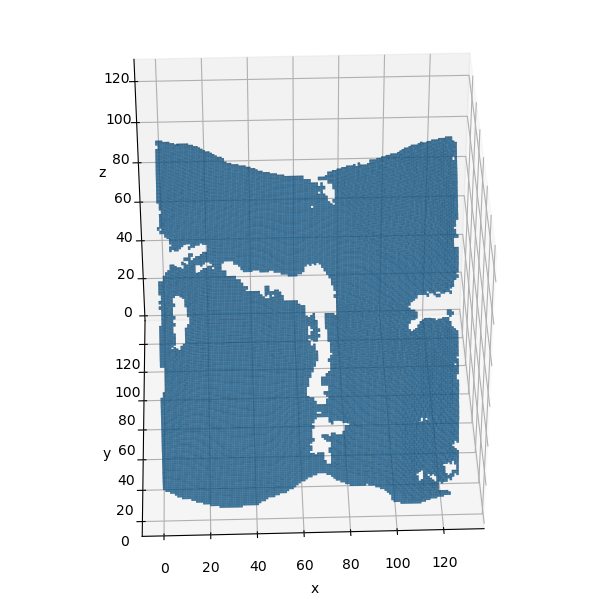
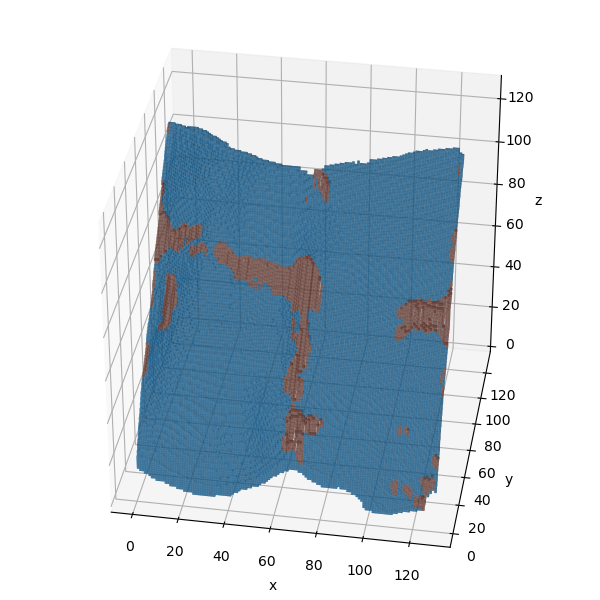